# 02. EDA — 창원국가산단 산업·고용 국면 분석

이 노트북은 `01_data_preprocessing.ipynb`의 산출물만 읽는다. **YoY·state·run·transition을
여기서 다시 계산하지 않는다.** 시각화를 위한 표현용 집계(지수화, 비중 정리, 국면 색상 매핑,
PPI 차감·EIS YoY 비교 등)만 이 노트북에서 만든다.

| 입력 | 역할 |
| --- | --- |
| `changwon_state_panel.csv` | 본분석기간(2022Q1~2026Q2) 10개 업종 × 분기 국면 패널 (180행) |
| `changwon_total_master.csv` | 참고기간(2018Q1~2026Q2) 산단 전체 장기 흐름 |
| `changwon_state_reference_panel.csv` | 참고용 전체기간(2018Q1~2026Q2) 패널. 2018~2021은 업종 재분류로 INVALID가 많아 이 노트북의 국면 시각화에는 사용하지 않음 |
| `ppi_validation_panel.csv` | PPI 검증 섹션 한정 (업종별 매핑 미확정 — 총지수만) |
| `eis_validation_panel.csv` | EIS 검증 섹션 한정 (2022Q1~2026Q2, KICOX와 모집단이 다름) |

## Setup

In [1]:
import sys
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Rectangle
from matplotlib.colors import ListedColormap, BoundaryNorm

# 국면 히트맵(F3)의 gridspec+sharey 조합에서 나오는 벤치마크성(무해한) tight_layout 경고만 숨긴다.
warnings.filterwarnings('ignore', message='This figure includes Axes')

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DIR_PROC = ROOT / 'data' / 'processed'
DIR_FIG = ROOT / 'outputs' / 'figures'
DIR_FIG.mkdir(parents=True, exist_ok=True)

state = pd.read_csv(DIR_PROC / 'kicox' / 'changwon_state_panel.csv')
total = pd.read_csv(DIR_PROC / 'kicox' / 'changwon_total_master.csv')

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = False
plt.rcParams['grid.alpha'] = 0.25
plt.rcParams['font.family'] = ['Malgun Gothic', 'sans-serif']   # 한글 라벨
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 10

# 국면 색상: 좋음/나쁨의 신호등 연상을 줄인 청·청록·황색·보라의 범주형 배색이다.
# 국면은 평가가 아닌 상태 분류이며, 노트북 전체가 이 딕셔너리 하나만 참조한다.
STATE_COLORS = {'S1': '#4C78A8', 'S2': '#72B7B2', 'S3': '#F2CF5B', 'S4': '#B279A2',
                'N': '#BDBDBD', 'INVALID': '#F2F2F2'}
STATE_LABELS = {'S1': 'S1 생산↑·고용↑', 'S2': 'S2 생산↑·고용↓',
                'S3': 'S3 생산↓·고용↑', 'S4': 'S4 생산↓·고용↓',
                'N': 'N 변화 없음(0%)', 'INVALID': 'INVALID 계산불가(결측)'}
STATES4 = ['S1', 'S2', 'S3', 'S4']
STATES5 = ['S1', 'S2', 'S3', 'S4', 'N']
STATES6 = ['S1', 'S2', 'S3', 'S4', 'N', 'INVALID']

# 고용비중 내림차순 업종 순서 — F3·F4·F5 등 정렬 기준으로 노트북 전체가 공유한다.
IND_ORDER_EMP = (state.groupby('industry').employment_share.mean()
                  .sort_values(ascending=False).index.tolist())
# 생산비중 상위 4개 업종(평균 합계 약 98%) — 심화 분석(F4)·규모 브래킷(F2) 공용
TOP4 = ['기계', '운송장비', '전기전자', '철강']


def style_ax(ax, ygrid=True):
    """상단/우측 spine 제거 + y축 grid만(옵션) — 전 Figure 공통 레이아웃 규칙."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.25) if ygrid else ax.grid(False)
    return ax


def save_fig(fig, name):
    fig.savefig(DIR_FIG / f'{name}.png', dpi=300, bbox_inches='tight')


print('state panel :', state.shape, state.quarter.min(), '~', state.quarter.max())
print('total master:', total.shape, total.quarter.min(), '~', total.quarter.max())
print('고용비중 내림차순 업종:', IND_ORDER_EMP)

state panel : (180, 123) 2022Q1 ~ 2026Q2
total master: (34, 25) 2018Q1 ~ 2026Q2
고용비중 내림차순 업종: ['기계', '전기전자', '운송장비', '철강', '음식료', '석유화학', '목재종이', '비금속', '기타', '섬유의복']


## Section 0. 분석 범위 및 데이터

In [2]:
print('본분석기간(state panel)          :', state.quarter.min(), '~', state.quarter.max())
print('업종 수                         :', state.industry.nunique())
print('관측치(업종 x 분기)              :', len(state))
print()
vc = state.state.value_counts()
print('상태 분포:')
print(vc.to_string())
print()
print(f"valid_state(S1~S4+N) 비율: {state.valid_state.mean():.1%}")
print(f"INVALID(결측/계산불가) 비율: {(state.state=='INVALID').mean():.1%}")
print(f"N(중립, 정확히 0) 비율: {(state.state=='N').mean():.1%}")

invalid_quarters = sorted(state.loc[state.state == 'INVALID', 'quarter'].unique())
blocks = []
q_all = sorted(state.quarter.unique())
cur = [q_all[0]]
for q in q_all[1:]:
    if q in invalid_quarters:
        blocks.append((cur[0], cur[-1]))
        cur = []
    else:
        cur.append(q)
if cur:
    blocks.append((cur[0], cur[-1]))

print()
print(f'INVALID 분기: {invalid_quarters}')
print('  -> 산발적 결측이 아니라 10개 업종 전체가 함께 비는 세로줄이며, 패널을 3개 관측 블록으로 끊는다:')
for b in blocks:
    n_q = q_all.index(b[1]) - q_all.index(b[0]) + 1
    print(f'     {b[0]}～{b[1]} ({n_q}분기)')
print('  -> Section 5(지속성)의 최장 run은 이 블록 길이 자체를 넘을 수 없다(양끝 절단 가능).')

본분석기간(state panel)          : 2022Q1 ~ 2026Q2
업종 수                         : 10
관측치(업종 x 분기)              : 180

상태 분포:
state
S1         54
S4         46
S2         43
INVALID    20
S3         13
N           4

valid_state(S1~S4+N) 비율: 88.9%
INVALID(결측/계산불가) 비율: 11.1%
N(중립, 정확히 0) 비율: 2.2%

INVALID 분기: ['2023Q4', '2024Q4']
  -> 산발적 결측이 아니라 10개 업종 전체가 함께 비는 세로줄이며, 패널을 3개 관측 블록으로 끊는다:
     2022Q1～2023Q3 (7분기)
     2024Q1～2024Q3 (3분기)
     2025Q1～2026Q2 (6분기)
  -> Section 5(지속성)의 최장 run은 이 블록 길이 자체를 넘을 수 없다(양끝 절단 가능).


## Section 1. 창원국가산단 전체 흐름

`changwon_total_master.csv`의 2018Q1~2026Q2 구간 생산·고용을 2018Q1=100 지수로 표시한다.
업종별 생산·고용 비중과 국면은 Section 2 이후에서 별도로 확인한다.

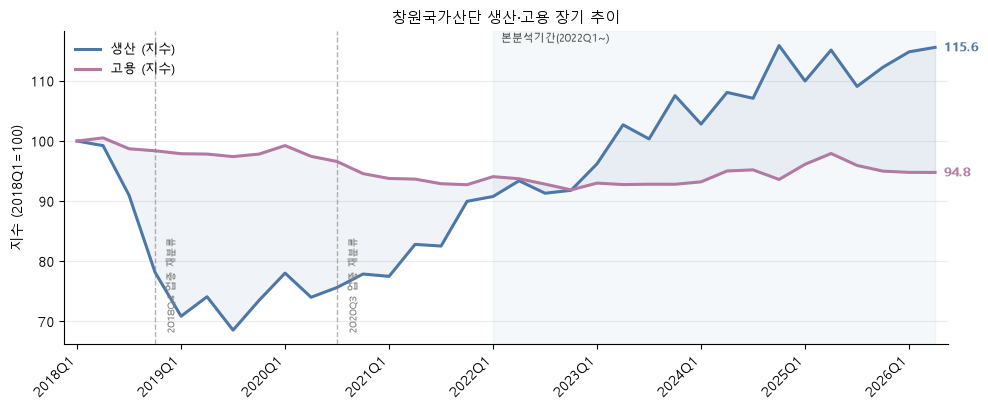

In [3]:
t = total.sort_values('quarter').reset_index(drop=True)
base_prod, base_emp = t.production_total.iloc[0], t.employment_total.iloc[0]
t['production_idx'] = t.production_total / base_prod * 100
t['employment_idx'] = t.employment_total / base_emp * 100

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(t.quarter, t.production_idx, color=STATE_COLORS['S1'], lw=2.2, label='생산 (지수)')
ax.plot(t.quarter, t.employment_idx, color=STATE_COLORS['S4'], lw=2.2, label='고용 (지수)')
ax.fill_between(range(len(t)), t.production_idx, t.employment_idx, color=STATE_COLORS['S1'], alpha=0.08)

main_start_i = int(t.index[t.quarter == '2022Q1'][0])
ax.axvspan(main_start_i, len(t) - 1, color=STATE_COLORS['S1'], alpha=0.05, zorder=0)
ax.text(main_start_i + 0.3, ax.get_ylim()[1] if False else 118, '본분석기간(2022Q1~)',
        fontsize=8, color='#555555', va='top', ha='left')

for q in ['2018Q4', '2020Q3']:
    qi = int(t.index[t.quarter == q][0])
    ax.axvline(qi, color='gray', ls='--', lw=1, alpha=0.6)
    ax.text(qi + 0.4, 68, f'{q} 업종 재분류', rotation=90, fontsize=7, color='gray', va='bottom', ha='left')

last = t.iloc[-1]
ax.annotate(f'{last.production_idx:.1f}', (len(t) - 1, last.production_idx), xytext=(6, 0),
            textcoords='offset points', va='center', fontsize=9.5, color=STATE_COLORS['S1'], fontweight='bold')
ax.annotate(f'{last.employment_idx:.1f}', (len(t) - 1, last.employment_idx), xytext=(6, 0),
            textcoords='offset points', va='center', fontsize=9.5, color=STATE_COLORS['S4'], fontweight='bold')

ax.set_title('창원국가산단 생산·고용 장기 추이', fontsize=11)
ax.set_ylabel('지수 (2018Q1=100)')
ax.set_xticks(range(0, len(t), 4))
ax.set_xticklabels(t.quarter[::4], rotation=45, ha='right')
ax.set_xlim(-0.5, len(t) - 0.5)
ax.legend(loc='upper left', frameon=False, fontsize=9)
style_ax(ax)
plt.tight_layout()
save_fig(fig, 'F1_총량_지수화')
plt.show()



### 관찰된 사실

- 2018Q1=100 기준으로 생산과 고용 지수의 분기별 경로가 서로 다르게 관측되었다.

### 해석상 주의

- 생산은 명목 생산액이므로 가격효과가 포함될 수 있으며, 두 지수의 동행 여부만으로 인과관계를 판단할 수 없다.

## Section 2. 업종별 생산·고용 규모 차이

`changwon_state_panel.csv`의 `production_share`·`employment_share`(2022Q1~2026Q2 평균)로
**분석단위의 규모 차이**만 먼저 확인한다. YoY 증감률 자체의 업종별 분포는 소규모 업종의 극단치
(예: 섬유의복 production_yoy 최대 약 700%)로 왜곡되므로, 실질적인 업종 비교는 국면 히트맵
(Section 4)에서 다룬다.

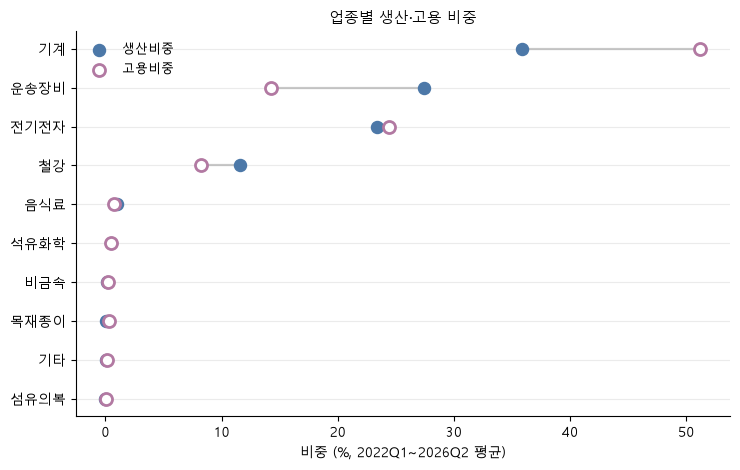

업종별 생산비중/고용비중 (%, 2022Q1~2026Q2 평균):
          production_share  employment_share
industry                                    
기계                   35.87             51.21
운송장비                 27.43             14.26
전기전자                 23.35             24.43
철강                   11.60              8.23
음식료                   1.01              0.70
석유화학                  0.49              0.52
비금속                   0.10              0.20
목재종이                  0.08              0.28
기타                    0.07              0.15
섬유의복                  0.01              0.03


In [4]:
share = state.groupby('industry')[['production_share', 'employment_share']].mean() * 100
share = share.sort_values('production_share', ascending=True)

fig, ax = plt.subplots(figsize=(7.5, 4.8))
y = np.arange(len(share))
for yi, ind in zip(y, share.index):
    p, e = share.loc[ind, 'production_share'], share.loc[ind, 'employment_share']
    ax.plot([p, e], [yi, yi], color='#C9C9C9', lw=1.6, zorder=1)
ax.scatter(share.production_share, y, color=STATE_COLORS['S1'], s=75, zorder=2, label='생산비중')
ax.scatter(share.employment_share, y, s=75, zorder=2, label='고용비중',
           facecolor='white', edgecolor=STATE_COLORS['S4'], linewidth=2)

ax.set_yticks(y); ax.set_yticklabels(share.index)
top4_prod = share.loc[TOP4, 'production_share'].sum()
top4_emp = share.loc[TOP4, 'employment_share'].sum()
ax.set_xlabel('비중 (%, 2022Q1~2026Q2 평균)')
ax.set_title('업종별 생산·고용 비중', fontsize=11)
ax.legend(loc='upper left', frameon=False, fontsize=9)
style_ax(ax)
plt.tight_layout()
save_fig(fig, 'F2_업종별_규모비중')
plt.show()

print('업종별 생산비중/고용비중 (%, 2022Q1~2026Q2 평균):')
print(share.round(2).sort_values('production_share', ascending=False).to_string())


### 관찰된 사실

- 2022Q1~2026Q2 평균 기준, 기계·운송장비·전기전자·철강의 합계 비중은 생산 98.3%, 고용 98.1%였다.
- 업종별 생산비중과 고용비중은 서로 다른 값으로 관측되었다.

### 해석상 주의

- 업종별 비중의 크기는 해당 업종의 중요도나 정책 우선순위를 뜻하지 않는다.

## Section 3. 생산·고용 4국면(S1~S4)

가장 최근 두 분기인 2026Q1과 2026Q2의 업종별 생산·고용 YoY 좌표와 분기 간 이동을 표시한다.

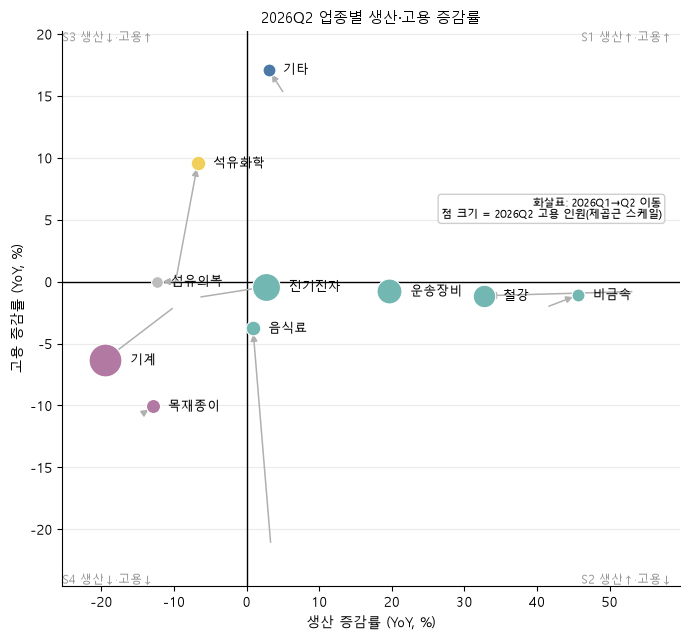

In [5]:
q12 = state[state.quarter.isin(['2026Q1', '2026Q2']) & state.valid_state].copy()
q1 = q12[q12.quarter == '2026Q1'].set_index('industry')
q2 = q12[q12.quarter == '2026Q2'].set_index('industry')
common_ind = [i for i in IND_ORDER_EMP if i in q1.index and i in q2.index]

fig, ax = plt.subplots(figsize=(7, 6.5))
ax.axhline(0, color='black', lw=1); ax.axvline(0, color='black', lw=1)

xpad = (q12.production_yoy.max() - q12.production_yoy.min()) * 0.08
ypad = (q12.employment_yoy.max() - q12.employment_yoy.min()) * 0.08
xlim = (q12.production_yoy.min() - xpad, q12.production_yoy.max() + xpad)
ylim = (q12.employment_yoy.min() - ypad, q12.employment_yoy.max() + ypad)
ax.set_xlim(xlim); ax.set_ylim(ylim)

quad_labels = {(1, 1): 'S1 생산↑·고용↑', (-1, 1): 'S3 생산↓·고용↑',
               (1, -1): 'S2 생산↑·고용↓', (-1, -1): 'S4 생산↓·고용↓'}
for (sx, sy), label in quad_labels.items():
    ax.text(xlim[1] if sx > 0 else xlim[0], ylim[1] if sy > 0 else ylim[0], label + '  ',
            ha='right' if sx > 0 else 'left', va='top' if sy > 0 else 'bottom',
            fontsize=8.5, color='#999999')

s_max = q2.employment.max()
for ind in common_ind:
    x0, y0 = q1.loc[ind, 'production_yoy'], q1.loc[ind, 'employment_yoy']
    x1, y1 = q2.loc[ind, 'production_yoy'], q2.loc[ind, 'employment_yoy']
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle='-|>', color='#B0B0B0', lw=1.1, shrinkA=4, shrinkB=4))
    size = 60 + 500 * np.sqrt(q2.loc[ind, 'employment'] / s_max)
    ax.scatter(x1, y1, s=size, color=STATE_COLORS.get(q2.loc[ind, 'state'], '#999999'),
               edgecolor='white', linewidth=0.8, zorder=3)
    label_dx = np.sqrt(size / np.pi) + 5   # 원 반지름만큼 띄워서 라벨이 원과 겹치지 않게
    ax.annotate(ind, (x1, y1), xytext=(label_dx, 0), textcoords='offset points', va='center', fontsize=9)

ax.set_aspect('auto')
ax.set_xlabel('생산 증감률 (YoY, %)'); ax.set_ylabel('고용 증감률 (YoY, %)')

down_emp = q2[q2.employment_yoy < 0]
down_prod_up = down_emp[down_emp.production_yoy > 0]
emp_share_map = state.groupby('industry').employment_share.mean()
share_pct = emp_share_map.loc[down_prod_up.index].sum() * 100
ax.set_title('2026Q2 업종별 생산·고용 증감률', fontsize=11)
ax.text(0.97, 0.68, '화살표: 2026Q1\u2192Q2 이동\n점 크기 = 2026Q2 고용 인원(제곱근 스케일)',
        transform=ax.transAxes, fontsize=8, va='center', ha='right',
        bbox=dict(boxstyle='round', fc='white', ec='#CCCCCC', alpha=0.95))
style_ax(ax)
plt.tight_layout()
save_fig(fig, 'F7_2026Q1_Q2_이동사분면')
plt.show()



### 관찰된 사실

- 2026Q2 고용 YoY가 음수인 7개 업종 중 5개 업종은 생산 YoY가 양수였다.
- 이 5개 업종의 평균 고용비중 합계는 47.8%였다.

### 해석상 주의

- 2026Q1과 2026Q2의 이동만으로 추세나 원인을 판단할 수 없다.

### S1~S4 정의

생산·고용 YoY의 부호 조합을 아래 4개 국면으로 분류한다. 본분석은 threshold=0(정확히 0%면 N)을 기준으로
하며, ±0.5/1/2%는 별도 민감도 패널이다.

| 국면 | 생산 YoY | 고용 YoY | 의미 |
| --- | :-: | :-: | --- |
| **S1 동반확대** | ↑ | ↑ | 생산과 고용이 함께 증가 |
| **S2 생산확대·고용감소** | ↑ | ↓ | 산업활동 확대와 고용 방향이 불일치 |
| **S3 생산감소·고용증가** | ↓ | ↑ | 생산 감소 속 고용은 증가 |
| **S4 동반감소** | ↓ | ↓ | 생산과 고용이 함께 감소 |
| **N** | 0% | 0% | 정확히 0 — INVALID(계산 불가)와는 다름 |

국면은 상태 분류이며 좋고 나쁨의 평가가 아니다. 전체 관측치 기준으로도 이 패턴이 일반적인지
아래에서 확인한다.

In [6]:
print('업종별 state 분포:')
print(pd.crosstab(state.industry, state.state).reindex(IND_ORDER_EMP).to_string())
print()
print('분기별 state 분포:')
print(pd.crosstab(state.quarter, state.state).to_string())
print()
emp_down = state[(state.employment_yoy < 0) & state.valid_state]
simple_pct = (emp_down.production_yoy > 0).mean()
weighted_pct = ((emp_down.production_yoy > 0).astype(float) * emp_down.employment).sum() / emp_down.employment.sum()
t4 = emp_down[emp_down.industry.isin(TOP4)]
t4_pct = (t4.production_yoy > 0).mean()
print(f'고용 감소 관측치 중 생산이 오히려 증가한 비율(전체기간, n={len(emp_down)}):')
print(f'  단순 비율        : {simple_pct:.1%}')
print(f'  고용 인원 가중    : {weighted_pct:.1%}')
print(f'  상위 4개 업종 한정: {t4_pct:.1%} (n={len(t4)})')


업종별 state 분포:
state     INVALID  N  S1  S2  S3  S4
industry                            
기계              2  0   5   5   1   5
전기전자            2  0   8   3   1   4
운송장비            2  0   6   7   1   2
철강              2  0   4   4   4   4
음식료             2  0   9   2   1   4
석유화학            2  0   7   0   5   4
목재종이            2  0   7   3   0   6
비금속             2  0   0  10   0   6
기타              2  0   5   4   0   7
섬유의복            2  4   3   5   0   4

분기별 state 분포:
state    INVALID  N  S1  S2  S3  S4
quarter                            
2022Q1         0  0   5   4   0   1
2022Q2         0  0   5   4   0   1
2022Q3         0  0   5   4   0   1
2022Q4         0  0   4   1   0   5
2023Q1         0  0   5   1   0   4
2023Q2         0  0   5   2   0   3
2023Q3         0  1   4   0   0   5
2023Q4        10  0   0   0   0   0
2024Q1         0  0   3   3   3   1
2024Q2         0  0   4   2   3   1
2024Q3         0  0   4   2   2   2
2024Q4        10  0   0   0   0   0
2025Q1         0  0   2

참고: ±0.5/1/2% 민감도 검사는 본분석(threshold=0)을 대체하지 않으며, 국면 경계 부근 관측치가 얼마나 민감한지 확인하는 용도다.

In [7]:
sens = pd.read_csv(DIR_PROC / 'kicox' / 'changwon_state_sensitivity_panel.csv')
print('민감도(threshold=0.5/1/2) — 본분석(threshold=0)과 별도 패널:')
print(sens.groupby('threshold').state.value_counts().unstack(fill_value=0).to_string())

민감도(threshold=0.5/1/2) — 본분석(threshold=0)과 별도 패널:
state      INVALID   N  S1  S2  S3  S4
threshold                             
0.5             20  11  51  41  11  46
1.0             20  23  50  33  11  43
2.0             20  47  41  29   7  36


## Section 4. 국면의 시간적 분포

10개 업종 × 18개 분기의 국면을 한 화면에 표시한다. 업종은 고용비중 내림차순으로 정렬한다.

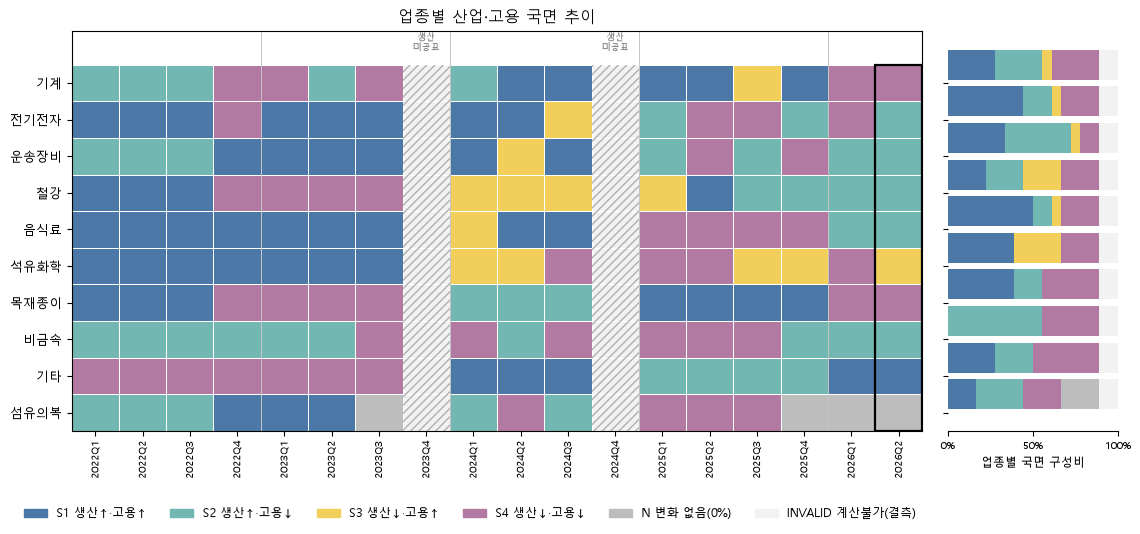

In [8]:
quarters = sorted(state.quarter.unique())
pivot = state.pivot(index='industry', columns='quarter', values='state').reindex(
    index=IND_ORDER_EMP, columns=quarters)
code_map = {s: i for i, s in enumerate(STATES6)}
code_arr = pivot.replace(code_map).astype(float).values

cmap = ListedColormap([STATE_COLORS[s] for s in STATES6])
norm = BoundaryNorm(np.arange(-0.5, 6.5, 1), cmap.N)

fig = plt.figure(figsize=(13.5, 5.2))
gs = fig.add_gridspec(1, 2, width_ratios=[5, 1], wspace=0.05)
ax = fig.add_subplot(gs[0])
axr = fig.add_subplot(gs[1], sharey=ax)

ax.pcolormesh(code_arr, cmap=cmap, norm=norm, edgecolors='white', linewidth=0.7)
ax.set_xticks(np.arange(len(quarters)) + 0.5)
ax.set_xticklabels(quarters, rotation=90, fontsize=7.5)
ax.set_yticks(np.arange(len(IND_ORDER_EMP)) + 0.5)
ax.set_yticklabels(IND_ORDER_EMP, fontsize=9.5)
ax.invert_yaxis()

for q in ['2023Q4', '2024Q4']:
    qi = quarters.index(q)
    for ri in range(len(IND_ORDER_EMP)):
        ax.add_patch(Rectangle((qi, ri), 1, 1, fill=False, hatch='////', edgecolor='#B0B0B0', linewidth=0))
    ax.text(qi + 0.5, -0.35, '생산\n미공표', ha='center', va='bottom', fontsize=6.3, color='#888888')

for i, q in enumerate(quarters):
    if q.endswith('Q1'):
        ax.axvline(i, color='#AAAAAA', lw=0.7, alpha=0.7)

last_qi = len(quarters) - 1
ax.add_patch(Rectangle((last_qi, 0), 1, len(IND_ORDER_EMP), fill=False, edgecolor='black', linewidth=1.6))

n_runs = state.dropna(subset=['run_id']).drop_duplicates('run_id')
share2plus = (n_runs.run_total_length >= 2).mean() * 100
ax.set_title('업종별 산업·고용 국면 추이', fontsize=11.5)

comp = pd.crosstab(state.industry, state.state, normalize='index').reindex(IND_ORDER_EMP)
comp = comp.reindex(columns=STATES6, fill_value=0)
left = np.zeros(len(comp))
yb = np.arange(len(comp))
for col in STATES6:
    axr.barh(yb, comp[col].values, left=left, color=STATE_COLORS[col], height=0.82)
    left += comp[col].values
axr.set_xlim(0, 1)
axr.set_xlabel('업종별 국면 구성비', fontsize=8.5)
axr.set_xticks([0, 0.5, 1]); axr.set_xticklabels(['0%', '50%', '100%'], fontsize=7.5)
plt.setp(axr.get_yticklabels(), visible=False)
style_ax(axr, ygrid=False)
axr.spines['left'].set_visible(False)

handles = [Rectangle((0, 0), 1, 1, color=STATE_COLORS[k]) for k in STATES6]
labels = [STATE_LABELS[k] for k in STATES6]
fig.legend(handles, labels, loc='lower center', ncol=6, bbox_to_anchor=(0.42, -0.08),
           frameon=False, fontsize=8.3)

plt.tight_layout()
save_fig(fig, 'F3_국면_히트맵')
plt.show()



### 관찰된 사실

- 전체 70개 run 중 39개(55.7%)가 2분기 이상 연속 관측되었다.
- 2023Q4와 2024Q4는 10개 업종 모두 INVALID로 표시되었다.

### 해석상 주의

- INVALID 열은 생산 미공표에 따른 결측이며 N이나 국면 전환을 뜻하지 않는다.

### 생산비중 상위 4개 업종 궤적

히트맵의 색이 실제로 어떤 생산·고용 움직임에서 나왔는지, 생산비중 상위 4개 업종(기계·운송장비·
전기전자·철강)만 확대해 확인한다. 나머지 6개 업종은 규모가 작아(Section 2) 이 패턴을 그대로
일반화하지 않는다.

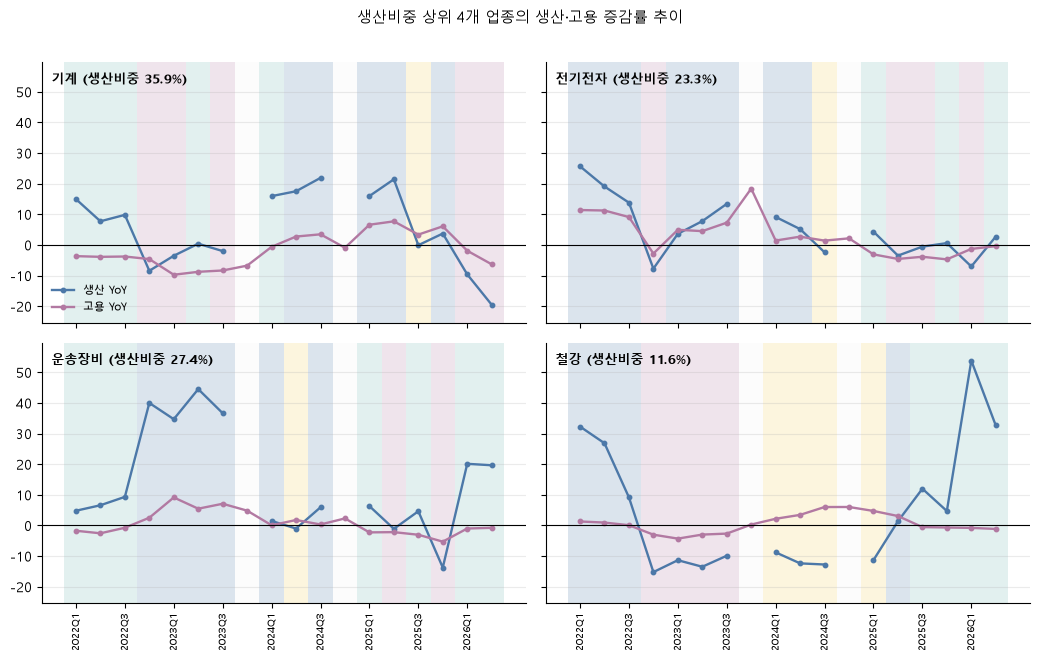

In [9]:
top4_order = [i for i in IND_ORDER_EMP if i in TOP4]
sub = state[state.industry.isin(TOP4)]
ymin = min(sub.production_yoy.min(), sub.employment_yoy.min())
ymax = max(sub.production_yoy.max(), sub.employment_yoy.max())
pad = (ymax - ymin) * 0.08
share_map = state.groupby('industry').production_share.mean() * 100

fig, axes = plt.subplots(2, 2, figsize=(10.5, 6.5), sharex=True, sharey=True)
for ax, ind in zip(axes.flat, top4_order):
    g = state[state.industry == ind].sort_values('quarter_index')
    for _, row in g.iterrows():
        ax.axvspan(row.quarter_index - 0.5, row.quarter_index + 0.5,
                   color=STATE_COLORS.get(row.state, 'white'), alpha=0.20, lw=0)
    ax.plot(g.quarter_index, g.production_yoy, color=STATE_COLORS['S1'], lw=1.7, marker='o', ms=3.2,
            label='생산 YoY')
    ax.plot(g.quarter_index, g.employment_yoy, color=STATE_COLORS['S4'], lw=1.7, marker='o', ms=3.2,
            label='고용 YoY')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_ylim(ymin - pad, ymax + pad)
    ax.set_xticks(g.quarter_index[::2])
    ax.set_xticklabels(g.quarter[::2], rotation=90, fontsize=7)
    ax.text(0.02, 0.96, f'{ind} (생산비중 {share_map[ind]:.1f}%)', transform=ax.transAxes,
            va='top', fontsize=9.5, fontweight='bold')
    style_ax(ax)

axes[0, 0].legend(loc='lower left', frameon=False, fontsize=8)
fig.suptitle('생산비중 상위 4개 업종의 생산·고용 증감률 추이', fontsize=11, y=1.01)
plt.tight_layout()
save_fig(fig, 'F4_4대업종_궤적')
plt.show()

### 관찰된 사실

- 기계·운송장비·전기전자·철강의 생산 YoY와 고용 YoY는 분기별로 서로 다른 경로를 보였다.
- 각 패널의 배경색은 해당 분기의 S1~S4·N·INVALID 분류를 나타낸다.

### 해석상 주의

- 네 업종의 경로를 다른 여섯 업종에 그대로 일반화할 수 없다.

## Section 5. 국면 지속성 (run)

같은 업종 내에서 동일 4상태(S1~S4)가 연속 분기에 이어질 때만 run으로 본다. INVALID를 만나면 끊긴다.
Section 0에서 확인한 3개 관측 블록(2022Q1–2023Q3 / 2024Q1–2024Q3 / 2025Q1–2026Q2) 때문에
**최장 run은 관측 가능한 블록 길이 자체가 상한**이다 — "몇 분기까지 갈 수 있었는지"가 아니라
"몇 분기까지 관측할 수 있었는지"에 가깝다.

In [10]:
runs = state.dropna(subset=['run_id']).drop_duplicates('run_id')
print('run_total_length 분포 (run 단위, 업종x분기 아님):')
print(runs.run_total_length.value_counts().sort_index().to_string())
print(f'평균 지속: {runs.run_total_length.mean():.2f}분기, 최장 지속: {runs.run_total_length.max():.0f}분기')
print()
longest = runs.sort_values('run_total_length', ascending=False).head(5)
print('최장 지속 사례 (모두 관측 블록 경계에 걸린 양끝 절단 가능성 있음):')
cols = ['industry', 'state', 'state_start_quarter', 'run_total_length', 'run_left_censored', 'run_right_censored']
print(longest[cols].to_string(index=False))

run_total_length 분포 (run 단위, 업종x분기 아님):
run_total_length
1.0    31
2.0    14
3.0    14
4.0     7
6.0     1
7.0     3
평균 지속: 2.23분기, 최장 지속: 7분기

최장 지속 사례 (모두 관측 블록 경계에 걸린 양끝 절단 가능성 있음):
industry state state_start_quarter  run_total_length  run_left_censored  run_right_censored
    석유화학    S1              2022Q1               7.0               True                True
      기타    S4              2022Q1               7.0               True                True
     음식료    S1              2022Q1               7.0               True                True
     비금속    S2              2022Q1               6.0               True               False
      기타    S2              2025Q1               4.0               True               False


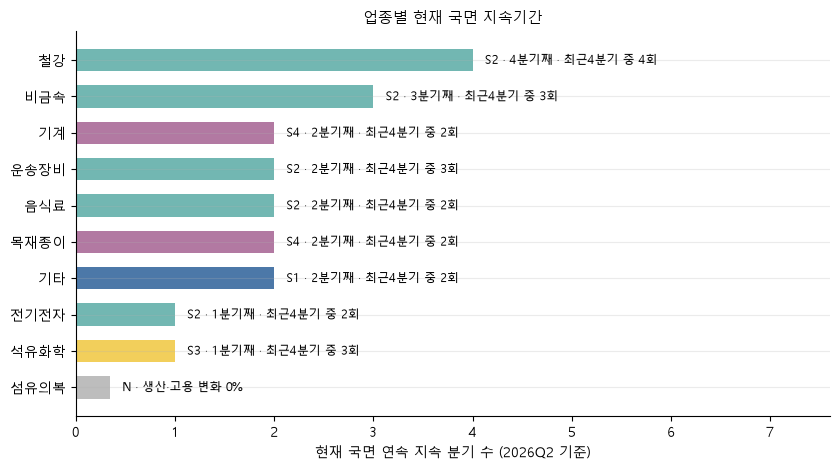

In [11]:
cur = state[state.quarter == '2026Q2'].set_index('industry').reindex(IND_ORDER_EMP)
emp_share = state.groupby('industry').employment_share.mean()
cur = cur.assign(run_len_sort=cur.run_length.fillna(-1), emp_share=emp_share)
cur = cur.sort_values(['run_len_sort', 'emp_share'], ascending=[False, False])

fig, ax = plt.subplots(figsize=(8.5, 4.8))
y = np.arange(len(cur))
colors = [STATE_COLORS.get(s, '#BDBDBD') for s in cur.state]
bar_len = cur.run_length.fillna(0.35)
ax.barh(y, bar_len, color=colors, height=0.62)
ax.set_yticks(y); ax.set_yticklabels(cur.index)
ax.invert_yaxis()
ax.set_xlabel('현재 국면 연속 지속 분기 수 (2026Q2 기준)')
ax.set_xlim(0, bar_len.max() + 3.6)

for yi, (ind, row) in zip(y, cur.iterrows()):
    if row.state == 'N':
        label = 'N · 생산·고용 변화 0%'
    else:
        recent = int(row[f'recent4_{row.state}_count'])
        label = f'{row.state} · {int(row.run_length)}분기째 · 최근4분기 중 {recent}회'
    ax.text(bar_len[ind] + 0.12, yi, label, va='center', fontsize=8.5)
    if bool(row.run_left_censored):
        ax.text(-0.25, yi, '\u25c1', va='center', ha='right', fontsize=10, color='#555555')

ax.set_title('업종별 현재 국면 지속기간', fontsize=11)
style_ax(ax)
plt.tight_layout()
save_fig(fig, 'F5_현재_지속_랭킹')
plt.show()



### 관찰된 사실

- 2026Q2 기준 S2는 5개 업종에서 관측되었고, 철강의 현재 S2 run은 4분기로 표시되었다.
- 기계·목재종이·기타·음식료·운송장비의 현재 run은 2분기로 표시되었다.

### 해석상 주의

- ◁ 표시는 run이 관측 블록 시작과 함께 시작해 실제 지속기간이 더 길 수 있음을 뜻한다. 지속 분기 수만으로 국면의 중요도를 판단할 수 없다.

참고: 2분기 이상 지속된 S2(생산확대·고용감소)/S4(동반감소) run 전체 목록과 2026Q2 기준 최근 4분기 국면 반복 횟수.

In [12]:
s2s4 = state[state.state.isin(['S2', 'S4']) & state.run_id.notna()].drop_duplicates('run_id')
print('S2/S4 run 중 2분기 이상 지속된 사례:')
print(s2s4[s2s4.run_total_length >= 2]
      [['industry', 'state', 'state_start_quarter', 'run_total_length']]
      .sort_values('run_total_length', ascending=False).to_string(index=False))
print()
print('최근 4분기 국면 반복(recent4_*), 2026Q2 기준, 업종은 고용비중순:')
print(state[state.quarter == '2026Q2'].set_index('industry').reindex(IND_ORDER_EMP)
      [['recent4_S1_count', 'recent4_S2_count', 'recent4_S3_count', 'recent4_S4_count']]
      .to_string())

S2/S4 run 중 2분기 이상 지속된 사례:
industry state state_start_quarter  run_total_length
      기타    S4              2022Q1               7.0
     비금속    S2              2022Q1               6.0
      기타    S2              2025Q1               4.0
    목재종이    S4              2022Q4               4.0
      철강    S2              2025Q3               4.0
      철강    S4              2022Q4               4.0
     음식료    S4              2025Q1               4.0
      기계    S2              2022Q1               3.0
    섬유의복    S4              2025Q1               3.0
    운송장비    S2              2022Q1               3.0
    섬유의복    S2              2022Q1               3.0
    목재종이    S2              2024Q1               3.0
     비금속    S4              2025Q1               3.0
     비금속    S2              2025Q4               3.0
      기계    S4              2026Q1               2.0
      기계    S4              2022Q4               2.0
    목재종이    S4              2026Q1               2.0
    석유화학    S4     

## Section 6. 국면 전환 (transition)

`t분기 상태 -> t+1분기 상태`의 **관측된 빈도**다. 미래 예측 확률이 아니다.

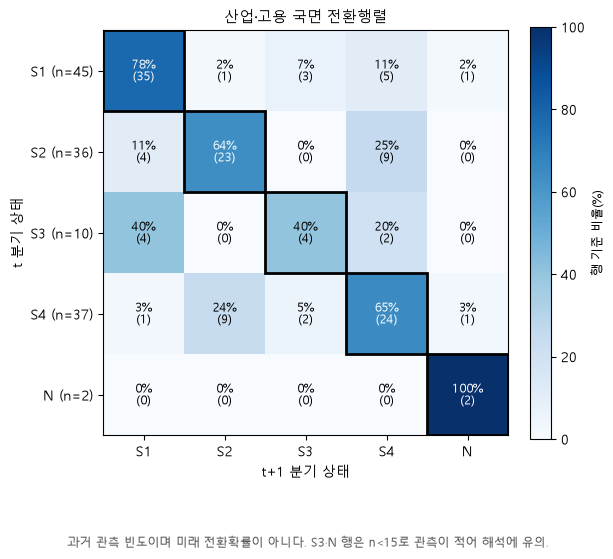

In [13]:
trans = state[state.valid_transition5 == True]
mat = pd.crosstab(trans.state, trans.next_state).reindex(index=STATES5, columns=STATES5, fill_value=0)
row_n = mat.sum(axis=1)
mat_pct = mat.div(row_n, axis=0).fillna(0) * 100
diag = sum(mat.loc[s, s] for s in STATES5)

fig, ax = plt.subplots(figsize=(6.2, 5.6))
im = ax.imshow(mat_pct.values, cmap='Blues', vmin=0, vmax=100)
ax.set_xticks(range(5)); ax.set_xticklabels(STATES5)
ax.set_yticks(range(5)); ax.set_yticklabels([f'{s} (n={row_n[s]})' for s in STATES5])
ax.set_xlabel('t+1 분기 상태'); ax.set_ylabel('t 분기 상태')
ax.set_title('산업·고용 국면 전환행렬', fontsize=11)

for i in range(5):
    for j in range(5):
        pct, cnt = mat_pct.values[i, j], mat.values[i, j]
        color = 'white' if pct > 55 else 'black'
        ax.text(j, i, f'{pct:.0f}%\n({cnt})', ha='center', va='center', fontsize=8.5, color=color)
for i in range(5):
    ax.add_patch(Rectangle((i - 0.5, i - 0.5), 1, 1, fill=False, edgecolor='black', linewidth=2))

cbar = plt.colorbar(im, ax=ax, fraction=0.046)
cbar.set_label('행 기준 비율(%)', fontsize=8.5)
fig.text(0.5, -0.04, '과거 관측 빈도이며 미래 전환확률이 아니다. S3·N 행은 n<15로 관측이 적어 해석에 유의.',
          ha='center', fontsize=8.3, color='#555555')
plt.tight_layout()
save_fig(fig, 'F6_전환행렬')
plt.show()



### 관찰된 사실

- 관측된 전환 130건 중 동일 상태로 이어진 전환은 88건(67.7%)이었다.
- 각 셀은 출발 상태별 행 기준 비율과 관측 건수를 함께 표시한다.

### 해석상 주의

- 이 행렬은 과거 관측 전환비중이며 미래 예측확률이 아니다. S3·N 행은 표본 수가 15건 미만이다.

## Section 7. 같은 국면 내 산업활동 차이

생산·고용 4국면을 1차 분류로 두고 가동률을 보조축으로 확인한다. 단, `op_rate_official`은
2024Q2부터, YoY 비교가 가능한 `op_rate_official_yoy_pp`는 **2025Q2~2026Q2 5개 분기(n=50)만**
존재한다. 이 구간을 넘는 진술은 하지 않는다. (`active_firm_ratio`는 state별 중앙값이
0.93~0.95로 차이가 거의 없고 소규모 업종에서 분모가 4~10사에 불과해 노이즈가 커 이 절에서는
다루지 않는다.)

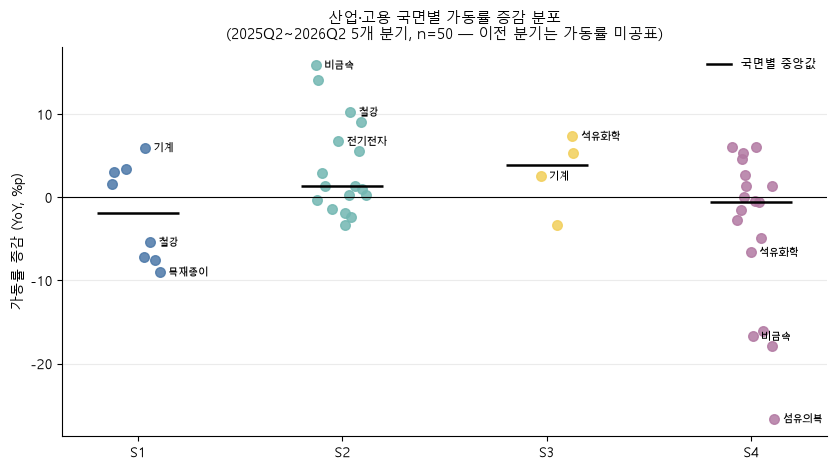

In [14]:
win = state[state.op_rate_official_yoy_pp.notna()].copy()
rng = np.random.default_rng(0)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
for xi, s in enumerate(STATES4):
    g = win[win.state == s]
    jitter = rng.uniform(-0.13, 0.13, size=len(g))
    jitter_map = dict(zip(g.index, jitter))
    ax.scatter(xi + jitter, g.op_rate_official_yoy_pp, color=STATE_COLORS[s], s=48, alpha=0.85, zorder=2)
    if len(g):
        med = g.op_rate_official_yoy_pp.median()
        ax.hlines(med, xi - 0.2, xi + 0.2, color='black', lw=1.8, zorder=3)
    top3 = (g.reindex(g.op_rate_official_yoy_pp.abs().sort_values(ascending=False).index)
             .drop_duplicates(subset='industry').head(3))
    for idx, row in top3.iterrows():
        ax.annotate(row.industry, (xi + jitter_map[idx], row.op_rate_official_yoy_pp),
                    xytext=(6, 0), textcoords='offset points', fontsize=7.5, va='center')

ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(range(4)); ax.set_xticklabels(STATES4)
ax.set_ylabel('가동률 증감 (YoY, %p)')
ax.set_title('산업·고용 국면별 가동률 증감 분포\n(2025Q2~2026Q2 5개 분기, n=50 — 이전 분기는 가동률 미공표)',
             fontsize=11)
ax.plot([], [], color='black', lw=1.8, label='국면별 중앙값')
ax.legend(loc='best', frameon=False, fontsize=8.5)
style_ax(ax)
plt.tight_layout()
save_fig(fig, 'F8_가동률_국면내_차이')
plt.show()



### 관찰된 사실

- 2025Q2~2026Q2의 가동률 YoY 관측치는 50건이며, S1~S4별 관측 수와 분포가 서로 달랐다.
- S2 관측치의 가동률 증감 범위는 -3.4%p~+15.9%p였다.

### 해석상 주의

- 분포 차이의 원인이 자동화, 인력부족, 외주화 등인지는 현재 데이터로 판단할 수 없다.

## Section 8. PPI 검증

KICOX 10개 업종과 PPI 세부품목의 공식 매핑이 아직 확정(승인)되지 않았다. **총지수 기준의
제한적 민감도만** 확인하며, 업종별 실질생산 변환은 하지 않는다. `real_production_yoy`는
이 절의 검증 목적을 위한 표현용 파생값이며, `production_yoy`(01 산출물)를 대체하지 않는다.

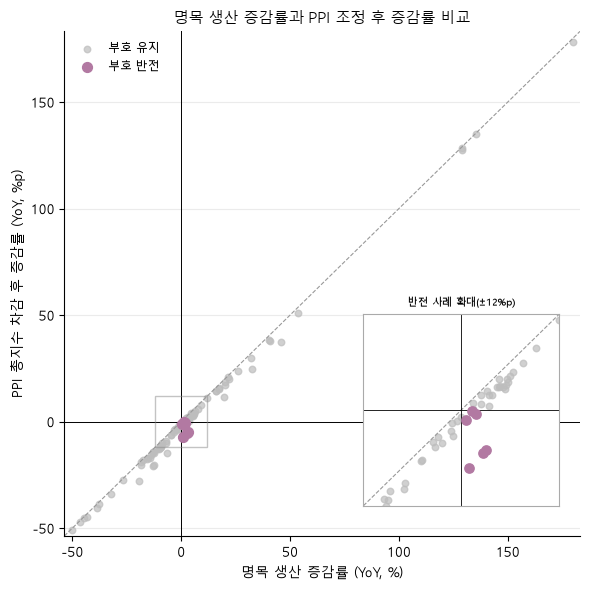

대상 90건 중 부호 반전 6건(6.7%).
부호 반전 사례:
quarter industry  production_yoy  real_production_yoy
 2024Q1       기타             1.3                 -0.1
 2024Q2       기타             1.7                 -0.5
 2026Q2       기타             3.0                 -5.1
 2026Q2      음식료             0.9                 -7.2
 2025Q4     전기전자             0.6                 -1.2
 2026Q2     전기전자             2.7                 -5.4

참고: 업종별 매핑 후보(전부 confirmed=False, 보류 — 실제 계산에는 쓰이지 않음)
kicox_industry ppi_candidate_item  confirmed
           음식료   음식료품(식료품/음료품/담배)      False
          섬유의복              섬유및의복      False
          목재종이   목재및목제품 + 펄프및종이제품      False
          석유화학     화학제품 + 석탄및석유제품      False
           비금속            비금속광물제품      False
            철강    1차금속제품(철강+비철금속)      False
            기계              기계및장비      False
          전기전자  전기장비 + 컴퓨터전자및광학기기      False
          운송장비   운송장비(자동차+기타운송장비)      False
            기타  공산품 잔여(기타제조업제품 등)      False


In [15]:
ppi = pd.read_csv(DIR_PROC / 'ppi' / 'ppi_validation_panel.csv')
mapping = pd.read_csv(DIR_PROC / 'ppi' / 'ppi_industry_mapping_candidates.csv')

m = state.merge(ppi[['quarter', 'ppi_total_index_yoy_pct']], on='quarter', how='inner')
m = m[m.production_yoy.notna() & m.ppi_total_index_yoy_pct.notna()].copy()
m['real_production_yoy'] = m.production_yoy - m.ppi_total_index_yoy_pct
m['flipped'] = (m.production_yoy > 0) != (m.real_production_yoy > 0)
pct_flip = m.flipped.mean() * 100

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(m.production_yoy, m.real_production_yoy, s=22, color='#BDBDBD', alpha=0.7, label='부호 유지', zorder=2)
flip = m[m.flipped]
ax.scatter(flip.production_yoy, flip.real_production_yoy, s=50, color=STATE_COLORS['S4'], zorder=3, label='부호 반전')
# 반전 사례는 원점 부근에 밀집해 개별 라벨이 겹치므로 표에서 확인한다(아래 print).

lo = min(m.production_yoy.min(), m.real_production_yoy.min()) - 3
hi = max(m.production_yoy.max(), m.real_production_yoy.max()) + 3
ax.plot([lo, hi], [lo, hi], color='#999999', lw=0.8, ls='--')
ax.axhline(0, color='black', lw=0.7); ax.axvline(0, color='black', lw=0.7)
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel('명목 생산 증감률 (YoY, %)')
ax.set_ylabel('PPI 총지수 차감 후 증감률 (YoY, %p)')
ax.set_title('명목 생산 증감률과 PPI 조정 후 증감률 비교', fontsize=10.8)
ax.legend(loc='upper left', frameon=False, fontsize=8.5)
style_ax(ax)

axins = ax.inset_axes([0.58, 0.06, 0.38, 0.38])
zoom = 12
axins.scatter(m.production_yoy, m.real_production_yoy, s=22, color='#BDBDBD', alpha=0.7)
axins.scatter(flip.production_yoy, flip.real_production_yoy, s=45, color=STATE_COLORS['S4'], zorder=3)
axins.plot([-zoom, zoom], [-zoom, zoom], color='#999999', lw=0.8, ls='--')
axins.axhline(0, color='black', lw=0.6); axins.axvline(0, color='black', lw=0.6)
axins.set_xlim(-zoom, zoom); axins.set_ylim(-zoom, zoom)
axins.set_xticks([]); axins.set_yticks([])
axins.set_title('반전 사례 확대(\u00b112%p)', fontsize=7.5)
for spine in axins.spines.values():
    spine.set_edgecolor('#AAAAAA')
ax.indicate_inset_zoom(axins, edgecolor='#888888')

plt.tight_layout()
save_fig(fig, 'A1_PPI_실질화_반전')
plt.show()

print(f'대상 {len(m)}건 중 부호 반전 {int(m.flipped.sum())}건({pct_flip:.1f}%).')
print('부호 반전 사례:')
print(flip[['quarter', 'industry', 'production_yoy', 'real_production_yoy']].round(1).to_string(index=False))
print()
print('참고: 업종별 매핑 후보(전부 confirmed=False, 보류 — 실제 계산에는 쓰이지 않음)')
print(mapping[['kicox_industry', 'ppi_candidate_item', 'confirmed']].to_string(index=False))

### 관찰된 사실

- 비교 가능한 90건 중 명목 생산 YoY와 PPI 총지수 차감 후 증감률의 부호가 다른 관측치는 6건(6.7%)이었다.

### 해석상 주의

- PPI 세부품목과 KICOX 업종의 공식 매핑이 확정되지 않아 총지수 차감 결과만 제시하며, 이를 업종별 실질생산으로 해석할 수 없다.

## Section 9. EIS 검증

`eis_validation_panel.csv`(2022Q1~2026Q2)의 실제 기간·변수를 그대로 사용한다. KICOX 산단
고용과 창원시 전체 고용보험 피보험자는 모집단(산단 입주기업 vs 창원시 전체)과 정의(현원 vs
피보험자)가 달라 **수준·비율·점유율을 계산하지 않고 방향(YoY)만 비교**한다.

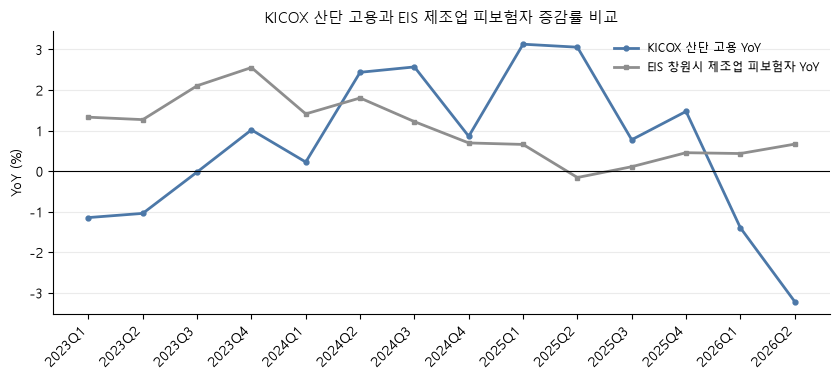

In [16]:
eis = pd.read_csv(DIR_PROC / 'eis' / 'eis_validation_panel.csv')

# KICOX 고용 YoY는 total_master에 없어 여기서 파생한다(표현용 집계, 국면 계산과 무관 — 01의 state/run/
# transition 산출 방식은 이 값을 참조하지 않는다).
tot_sorted = total.sort_values('quarter').reset_index(drop=True)
tot_sorted['employment_total_yoy'] = tot_sorted.employment_total.pct_change(4) * 100

merged = eis[['quarter', 'eis_manufacturing_yoy_pct']].merge(
    tot_sorted[['quarter', 'employment_total_yoy']], on='quarter', how='inner').dropna()

fig, ax = plt.subplots(figsize=(8.5, 3.9))
ax.plot(merged.quarter, merged.employment_total_yoy, color=STATE_COLORS['S1'], lw=2, marker='o', ms=3.5,
        label='KICOX 산단 고용 YoY')
ax.plot(merged.quarter, merged.eis_manufacturing_yoy_pct, color='#8E8E8E', lw=2, marker='s', ms=3.5,
        label='EIS 창원시 제조업 피보험자 YoY')
ax.axhline(0, color='black', lw=0.8)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_ylabel('YoY (%)')

ax.set_title('KICOX 산단 고용과 EIS 제조업 피보험자 증감률 비교', fontsize=10.8)
ax.legend(loc='best', frameon=False, fontsize=8.5)
style_ax(ax)
plt.tight_layout()
save_fig(fig, 'F9_EIS_YoY_비교')
plt.show()



### 관찰된 사실

- 2026Q2 KICOX 산단 고용 YoY는 -3.2%, EIS 창원시 제조업 피보험자 YoY는 +0.7%였다.

### 해석상 주의

- 두 지표는 모집단과 통계 정의가 달라 수준·비율·점유율을 직접 비교할 수 없으며, 차이의 원인을 현재 데이터로 판단할 수 없다.

## Section 10. 핵심 EDA 결과

데이터가 직접 보여주는 것과, 다음 단계에서 확인할 사항을 구분해 정리한다.

In [17]:
print('=== 핵심 수치 요약 ===')
print(f'- 고용 감소 관측치 중 생산 증가 비율: 단순 {simple_pct:.1%} (n={len(emp_down)}) / '
      f'고용가중 {weighted_pct:.1%} / 4대업종 한정 {t4_pct:.1%}')
print(f'- 전체 run 중 2분기 이상 지속 비율: {share2plus:.0f}% (n={len(n_runs)})')
print(f'- 관측된 전환 {len(trans)}건 중 국면 유지 비율: {diag/len(trans):.1%}')
print(f'- PPI 실질화 후 부호 반전 비율: {pct_flip:.1f}% (n={len(m)})')
print(f'- 생산비중/고용비중 상위 4개 업종 합계: 생산 {top4_prod:.1f}% / 고용 {top4_emp:.1f}%')

=== 핵심 수치 요약 ===
- 고용 감소 관측치 중 생산 증가 비율: 단순 48.3% (n=89) / 고용가중 53.0% / 4대업종 한정 55.9%
- 전체 run 중 2분기 이상 지속 비율: 56% (n=70)
- 관측된 전환 130건 중 국면 유지 비율: 67.7%
- PPI 실질화 후 부호 반전 비율: 6.7% (n=90)
- 생산비중/고용비중 상위 4개 업종 합계: 생산 98.3% / 고용 98.1%


| 연구질문 | 데이터가 직접 확인한 것 | 간접적으로 시사하는 것 | 현재 데이터로 판단할 수 없는 것 |
| --- | --- | --- | --- |
| 업종별 생산·고용 규모는 어떻게 다른가? | 생산비중 상위 4개 업종의 평균 합계는 생산 98.3%, 고용 98.1%였다. | 전체 지표와 업종별 지표를 함께 볼 필요가 있다. | 비중에 따른 정책 우선순위나 업종의 중요도 |
| 고용 감소 관측에서 생산 방향은 어떠한가? | 고용 감소 관측 중 생산 증가 비율은 단순 48.3%, 고용 인원 가중 53.0%였다. | 고용 증감만으로 생산 방향을 구분하기 어려운 사례가 존재한다. | 생산과 고용 방향 차이의 원인 |
| 국면은 몇 분기 이어지고 어떻게 전환되는가? | 전체 70개 run 중 39개가 2분기 이상이었고, 전환 130건 중 88건은 동일 상태로 이어졌다. | 한 분기만의 상태가 아닌 사례가 존재한다. | 개별 업종의 미래 상태와 확정 지속기간 |
| 같은 국면의 가동률 증감은 어떠한가? | 2025Q2~2026Q2의 50개 관측에서 국면별 가동률 증감 분포가 서로 달랐다. | 생산·고용 방향 외 보조지표를 함께 확인할 필요가 있다. | 자동화·인력부족·외주화 등이 분포 차이의 원인인지 여부 |
| PPI 조정 전후 생산 방향은 어떠한가? | 비교 가능한 90건 중 부호가 다른 관측치는 6건(6.7%)이었다. | 총지수 차감 기준에서 경계 관측치의 분류가 달라질 수 있다. | 업종별 실질생산과 물가효과의 정확한 크기 |
| KICOX와 EIS 고용 YoY는 어떻게 관측되는가? | 2026Q2 KICOX는 -3.2%, EIS는 +0.7%였다. | 서로 다른 모집단의 고용 방향을 병행 점검할 필요가 있다. | 두 지표 차이의 원인과 산단 안팎의 고용 이동 |

인과관계와 정책효과는 이 EDA에서 단정하지 않는다.

## Section 11. 해석상 주의점

- 4국면(S1~S4)은 상관관계 표현이며 인과를 의미하지 않는다. 국면은 상태 분류이지 좋고 나쁨의
  평가가 아니다(색상도 이를 반영해 청·청록·황색·보라의 범주형 배색을 사용했다).
- INVALID(2023Q4·2024Q4)는 10개 업종 전체가 결측되는 구조적 결측이며 N(정확히 0, 중립)과
  다르다. 이로 인해 관측 패널이 2022Q1–2023Q3 / 2024Q1–2024Q3 / 2025Q1–2026Q2 3개 블록으로
  끊기며, Section 5의 최장 run(7분기)은 실제 지속기간이 아니라 관측 블록 길이 상한이다(양끝
  절단 가능).
- 전환 빈도/비율(Section 6)은 과거 관측치이며 미래 예측 확률이 아니다. S3·N 행은 n<15로
  관측이 적어 해석에 유의한다.
- 가동률 YoY(Section 7)는 2025Q2~2026Q2 5개 분기(n=50)만 존재하며, 그 이전 기간에 대한
  진술로 확장하지 않는다.
- ±0.5/1/2% 민감도는 본분석 state(threshold=0)를 대체하지 않는다.
- production_total·production은 명목 생산액이며 가격효과가 포함될 수 있다(Section 8 PPI
  검증은 총지수 기준의 제한적 민감도만 제공하고, 업종별 매핑은 사용자 승인 전까지 적용하지
  않는다).
- EIS(Section 9)는 KICOX와 모집단·통계 정의가 달라 수준값을 합산·대체하지 않으며 방향(YoY)만
  참고한다.
- 업종 내 개별 기업 차이, 정책 효과, 인과관계는 이 EDA에서 검증하지 않는다.